## Pakistani Politicians Classifier Training
* Model (EfficientNet-B0)
* Tracking using mlflow saved on dagshub
* Transfer learning unfreeze last few EfficientNet feature blocks
* Classifier-only tuning freeze all backbone layers and train only final classifier

In [1]:
!pip install dagshub mlflow dvc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 112.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import json
import os
import random
from pathlib import Path
from getpass import getpass

import dagshub
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

## Connect Github & Dagshub

In [3]:
GITHUB_TOKEN = getpass()
print("Please paste your NEW GitHub Token below and press Enter:")


GITHUB_TOKEN = GITHUB_TOKEN.strip()
USERNAME = "M-Abdullah-Ali-2468"
REPO_NAME = "Pakistani-Politician-Image-Classification-using-CNNs"

repo_url = f"https://{GITHUB_TOKEN}@github.com/{USERNAME}/{REPO_NAME}.git"
clone_cmd = f"git clone {repo_url}"

exit_code = os.system(clone_cmd)

if exit_code == 0:
    os.chdir(REPO_NAME)
    print(f"✅ Success! You are now inside: {os.getcwd()}")
else:
    print("❌ Clone failed")

Please paste your NEW GitHub Token below and press Enter:
✅ Success! You are now inside: /content/Pakistani-Politician-Image-Classification-using-CNNs


In [4]:
!ls

data  main.py  README.md  requirements.txt  scripts


In [5]:
DAGSHUB_USER = "RudhanLodhi"
print("Enter  DagsHub key:")
DAGSHUB_TOKEN = getpass().strip()

os.system('dvc remote modify origin --local auth basic')
os.system(f'dvc remote modify origin --local user {DAGSHUB_USER}')
os.system(f'dvc remote modify origin --local password {DAGSHUB_TOKEN}')

exit_code = os.system('dvc pull')

if exit_code == 0:
    print("✅ Success! Your images have been downloaded.")
else:
    print("❌ Error: dvc pull failed. ")

Enter  DagsHub key:
✅ Success! Your images have been downloaded.


In [7]:
!ls data/split

test  train  val


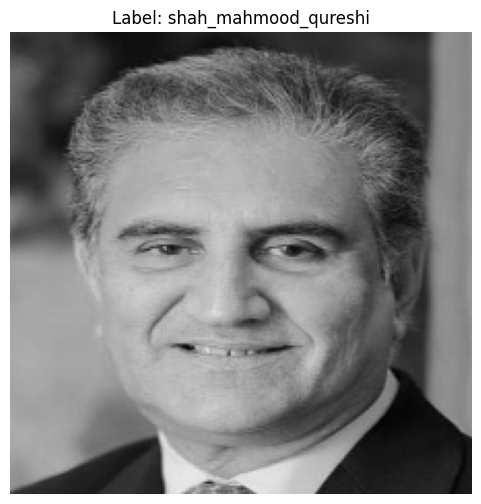

In [9]:
train_root = Path("data/split/train")

class_dirs = [p for p in train_root.iterdir() if p.is_dir()]
label_dir = random.choice(class_dirs)
image_files = [p for p in label_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}]

img_path = random.choice(image_files)
img = plt.imread(img_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Label: {label_dir.name}")
plt.axis("off")
plt.show()

In [11]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

base_dir = Path("data/split") 
train_dir = base_dir / "train"
val_dir = base_dir / "val"
test_dir = base_dir / "test"

for path in [train_dir, val_dir, test_dir]:
    if not path.exists():
        raise FileNotFoundError(f"❌ Missing folder: {path.absolute()}")
    else:
        print(f"✅ Found: {path}")

✅ Found: data/split/train
✅ Found: data/split/val
✅ Found: data/split/test


## Setup Mlflow 

In [28]:
CONFIG = {
    "seed": 42,
    "img_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "epochs": 30,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "label_smoothing": 0.1,
    "early_stopping_patience": 5,
    "classifier_dropout": 0.3,
    "unfreeze_last_n_blocks": 2, 
    "model_name": "efficientnet_b0",
    "experiment_name": "pakistan-politician-classification",
    "run_name": "efficientnetb0-transfer-learning",
}

REPO_OWNER = "f230046"
REPO_NAME = "Pakistani-Politician-Image-Classification-using-CNNs"

print(f"Connecting to DagsHub: {REPO_OWNER}/{REPO_NAME}...")

dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_experiment(CONFIG["experiment_name"])

print(f"✅ MLflow is active and tracking remotely to: {mlflow.get_tracking_uri()}")

Connecting to DagsHub: f230046/Pakistani-Politician-Image-Classification-using-CNNs...


Initialized MLflow to track repo "f230046/Pakistani-Politician-Image-Classification-using-CNNs"

Repository f230046/Pakistani-Politician-Image-Classification-using-CNNs initialized!

✅ MLflow is active and tracking remotely to: https://dagshub.com/f230046/Pakistani-Politician-Image-Classification-using-CNNs.mlflow


In [17]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG["img_size"], scale=(0.8, 1.0)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.25),
    transforms.ToTensor(),
    normalize,
])

eval_transforms = transforms.Compose([
    transforms.Resize(256),                     
    transforms.CenterCrop(CONFIG["img_size"]),  
    transforms.ToTensor(),
    normalize,
])

train_ds = datasets.ImageFolder(train_dir, transform=train_transforms)
val_ds = datasets.ImageFolder(val_dir, transform=eval_transforms)
test_ds = datasets.ImageFolder(test_dir, transform=eval_transforms)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Classes found: {class_names}")
print(f"Number of classes: {num_classes}")

Classes found: ['ahmed_sharif_chaudhry', 'asif_ali_zardari', 'benazir_bhutto', 'bilawal_bhutto', 'fazl_ur_rehman', 'hina_rabbani_khar', 'imran_khan', 'khawaja_asif', 'khawaja_saad_rafique', 'maryam_nawaz', 'nawaz_sharif', 'pervez_musharraf', 'shah_mahmood_qureshi', 'shehbaz_sharif', 'sheikh_rasheed', 'yousuf_raza_gillani']
Number of classes: 16


In [18]:
train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

print(f"✅ Classes ({num_classes}): {class_names}")
print(f"✅ Train/Val/Test sizes: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

✅ Classes (16): ['ahmed_sharif_chaudhry', 'asif_ali_zardari', 'benazir_bhutto', 'bilawal_bhutto', 'fazl_ur_rehman', 'hina_rabbani_khar', 'imran_khan', 'khawaja_asif', 'khawaja_saad_rafique', 'maryam_nawaz', 'nawaz_sharif', 'pervez_musharraf', 'shah_mahmood_qureshi', 'shehbaz_sharif', 'sheikh_rasheed', 'yousuf_raza_gillani']
✅ Train/Val/Test sizes: 960/192/128


## Model Preperation

In [19]:
def build_model(num_classes: int, unfreeze_last_n_blocks: int = 2):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    for p in model.parameters():
        p.requires_grad = False


    total_blocks = len(model.features)
    if unfreeze_last_n_blocks > 0:
        start_idx = max(0, total_blocks - unfreeze_last_n_blocks)
        for idx in range(start_idx, total_blocks):
            for p in model.features[idx].parameters():
                p.requires_grad = True

    # Replace classifier head with task-specific layer.
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=CONFIG["classifier_dropout"]),
        nn.Linear(in_features, num_classes),
    )

    return model

In [20]:
def count_trainable_params(model: nn.Module):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def epoch_step(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    running_loss = 0.0
    running_correct = 0
    n_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(images)
            loss = criterion(logits, labels)

            if train_mode:
                loss.backward()
                optimizer.step()

        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == labels).sum().item()
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    avg_loss = running_loss / max(1, n_samples)
    avg_acc = running_correct / max(1, n_samples)
    return avg_loss, avg_acc


In [21]:
def collect_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    return np.array(y_true), np.array(y_pred)

## Model Training

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [36]:
# 1. Create Local Artifacts Directory
artifacts_dir = Path("logiing/")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# 2. Build Model & Count Parameters
model = build_model(
    num_classes=num_classes,
    unfreeze_last_n_blocks=CONFIG["unfreeze_last_n_blocks"],
).to(device)

trainable_params, total_params = count_trainable_params(model)
print(f"✅ Model initialized on {device}.")
print(f"📊 Trainable parameters: {trainable_params:,} / {total_params:,}")

✅ Model initialized on cuda.
📊 Trainable parameters: 1,149,888 / 4,028,044


In [37]:
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])
optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

In [38]:
best_val_acc = 0.0
best_state_dict = None
epochs_without_improvement = 0
history = []

print("🚀 Starting Training Loop...\n")

with mlflow.start_run(run_name=CONFIG["run_name"]) as run:
    # Log initial configuration
    mlflow.log_params(CONFIG)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("trainable_params", int(trainable_params))
    mlflow.log_param("total_params", int(total_params))
    mlflow.log_param("class_names", json.dumps(class_names))

    # The Training Loop
    for epoch in range(1, CONFIG["epochs"] + 1):
        train_loss, train_acc = epoch_step(model, train_loader, criterion, optimizer)
        val_loss, val_acc = epoch_step(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_acc)
        lr_now = optimizer.param_groups[0]["lr"]

        # Log to MLflow
        mlflow.log_metric("train_loss", float(train_loss), step=epoch)
        mlflow.log_metric("train_acc", float(train_acc), step=epoch)
        mlflow.log_metric("val_loss", float(val_loss), step=epoch)
        mlflow.log_metric("val_acc", float(val_acc), step=epoch)
        mlflow.log_metric("lr", float(lr_now), step=epoch)

        history.append({
            "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc, "lr": lr_now,
        })

        print(
            f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={lr_now:.2e}"
        )

        # Early Stopping Check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
            print("🛑 Early stopping triggered.")
            break

    # Load the best weights back into the model for evaluation
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    
    print(f"\n🎉 Training Complete! Best Val Acc: {best_val_acc:.4f}")
    
    # Ensure this code is aligned properly if placed in the same Colab block, 
    # or combined with Cell 2 if Colab drops the context manager across cells.
    
    print("📊 Generating plots and evaluating on Test Set...")
    
    # 1. Save and log training history CSV
    history_df = pd.DataFrame(history)
    history_csv = artifacts_dir / "history.csv"
    history_df.to_csv(history_csv, index=False)
    mlflow.log_artifact(str(history_csv), artifact_path="metrics")

    # 2. Plot Training vs Validation Curves (Mandatory Rubric Item)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title("Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
    axes[1].set_title("Accuracy Curves")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    curves_path = artifacts_dir / "training_curves.png"
    fig.savefig(curves_path, dpi=150)
    plt.close(fig)
    mlflow.log_artifact(str(curves_path), artifact_path="plots")

    # 3. Evaluate on the 10% Test Set
    model.to(device) # Ensure it is back on GPU
    test_loss, test_acc = epoch_step(model, test_loader, criterion, optimizer=None)
    mlflow.log_metric("test_loss", float(test_loss))
    mlflow.log_metric("test_acc", float(test_acc))
    print(f"🎯 Final Test Accuracy: {test_acc:.4f}")

    # 4. Generate Confusion Matrix & Classification Report
    y_true, y_pred = collect_predictions(model, test_loader)
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose()

    report_csv = artifacts_dir / "classification_report.csv"
    report_df.to_csv(report_csv, index=True)
    mlflow.log_artifact(str(report_csv), artifact_path="reports")

    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax_cm)
    ax_cm.set_title("Confusion Matrix (Test)")
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("True")
    plt.tight_layout()
    cm_path = artifacts_dir / "confusion_matrix.png"
    fig_cm.savefig(cm_path, dpi=150)
    plt.close(fig_cm)
    mlflow.log_artifact(str(cm_path), artifact_path="plots")
    
    print("📦 Packaging model for deployment...")
    
    # 1. Save Deployment Metadata
    metadata = {
        "model_name": CONFIG["model_name"],
        "img_size": CONFIG["img_size"],
        "class_names": class_names,
        "normalization": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225],
        },
    }
    metadata_path = artifacts_dir / "inference_metadata.json"
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
    mlflow.log_artifact(str(metadata_path), artifact_path="deployment")

    input_example = torch.randn(1, 3, CONFIG["img_size"], CONFIG["img_size"])
    model_signature = mlflow.models.infer_signature(
        input_example.numpy(),
        model(input_example.to(device)).detach().cpu().numpy(),
    )

    mlflow.pytorch.log_model(
        pytorch_model=model.cpu(),
        artifact_path="model",
        signature=model_signature,
        input_example=input_example.numpy(),
        metadata={"class_names": class_names},
    )

    # 3. Final Output
    artifact_uri = run.info.artifact_uri
    print("\n✅ Run finished completely:")
    print("Run ID:", run.info.run_id)
    print("Artifact URI:", artifact_uri)
    

🚀 Starting Training Loop...

Epoch 01/30 | train_loss=2.0984 train_acc=0.4552 | val_loss=1.2943 val_acc=0.7604 | lr=1.00e-03
Epoch 02/30 | train_loss=1.1237 train_acc=0.8469 | val_loss=1.0790 val_acc=0.8333 | lr=1.00e-03
Epoch 03/30 | train_loss=0.8751 train_acc=0.9385 | val_loss=0.9222 val_acc=0.8906 | lr=1.00e-03
Epoch 04/30 | train_loss=0.7852 train_acc=0.9594 | val_loss=0.8929 val_acc=0.9062 | lr=1.00e-03
Epoch 05/30 | train_loss=0.7531 train_acc=0.9656 | val_loss=0.8599 val_acc=0.9167 | lr=1.00e-03
Epoch 06/30 | train_loss=0.7262 train_acc=0.9844 | val_loss=0.8435 val_acc=0.9271 | lr=1.00e-03
Epoch 07/30 | train_loss=0.6985 train_acc=0.9927 | val_loss=0.8274 val_acc=0.9375 | lr=1.00e-03
Epoch 08/30 | train_loss=0.6916 train_acc=0.9927 | val_loss=0.8161 val_acc=0.9323 | lr=1.00e-03
Epoch 09/30 | train_loss=0.6835 train_acc=0.9917 | val_loss=0.7972 val_acc=0.9583 | lr=1.00e-03
Epoch 10/30 | train_loss=0.6804 train_acc=0.9927 | val_loss=0.7938 val_acc=0.9635 | lr=1.00e-03
Epoch 11/30

2026/05/11 22:55:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 22:55:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/11 22:55:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/11 22:55:46 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version


✅ Run finished completely:
Run ID: a255f3d0e0f14de5b698cfbb0ad09c45
Artifact URI: mlflow-artifacts:/8cb21d6c45ff4f77b31264298e7bb6ee/a255f3d0e0f14de5b698cfbb0ad09c45/artifacts
🏃 View run efficientnetb0-transfer-learning at: https://dagshub.com/f230046/Pakistani-Politician-Image-Classification-using-CNNs.mlflow/#/experiments/0/runs/a255f3d0e0f14de5b698cfbb0ad09c45
🧪 View experiment at: https://dagshub.com/f230046/Pakistani-Politician-Image-Classification-using-CNNs.mlflow/#/experiments/0


## Training only classifier, Model: efficientnet_b0

In [41]:
CONFIG = {
    "seed": 42,
    "img_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "epochs": 30,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "label_smoothing": 0.1,
    "early_stopping_patience": 5,
    "classifier_dropout": 0.3,
    "unfreeze_last_n_blocks": 0, 
    "model_name": "efficientnet_b0",
    "experiment_name": "pakistan-politician-classification",
    "run_name": "efficientnetb0-classifier-only",
}

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [42]:
# 1. Create Local Artifacts Directory
artifacts_dir = Path("logiing/")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# 2. Build Model & Count Parameters
model = build_model(
    num_classes=num_classes,
    unfreeze_last_n_blocks=CONFIG["unfreeze_last_n_blocks"],
).to(device)

trainable_params, total_params = count_trainable_params(model)
print(f"✅ Model initialized on {device}.")
print(f"📊 Trainable parameters: {trainable_params:,} / {total_params:,}")

✅ Model initialized on cuda.
📊 Trainable parameters: 20,496 / 4,028,044


In [43]:
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])
optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

In [44]:
best_val_acc = 0.0
best_state_dict = None
epochs_without_improvement = 0
history = []

print("🚀 Starting Training Loop...\n")

with mlflow.start_run(run_name=CONFIG["run_name"]) as run:
    # Log initial configuration
    mlflow.log_params(CONFIG)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("trainable_params", int(trainable_params))
    mlflow.log_param("total_params", int(total_params))
    mlflow.log_param("class_names", json.dumps(class_names))

    # The Training Loop
    for epoch in range(1, CONFIG["epochs"] + 1):
        train_loss, train_acc = epoch_step(model, train_loader, criterion, optimizer)
        val_loss, val_acc = epoch_step(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_acc)
        lr_now = optimizer.param_groups[0]["lr"]

        # Log to MLflow
        mlflow.log_metric("train_loss", float(train_loss), step=epoch)
        mlflow.log_metric("train_acc", float(train_acc), step=epoch)
        mlflow.log_metric("val_loss", float(val_loss), step=epoch)
        mlflow.log_metric("val_acc", float(val_acc), step=epoch)
        mlflow.log_metric("lr", float(lr_now), step=epoch)

        history.append({
            "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc, "lr": lr_now,
        })

        print(
            f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={lr_now:.2e}"
        )

        # Early Stopping Check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
            print("🛑 Early stopping triggered.")
            break

    # Load the best weights back into the model for evaluation
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    
    print(f"\n🎉 Training Complete! Best Val Acc: {best_val_acc:.4f}")
    
    # Ensure this code is aligned properly if placed in the same Colab block, 
    # or combined with Cell 2 if Colab drops the context manager across cells.
    
    print("📊 Generating plots and evaluating on Test Set...")
    
    # 1. Save and log training history CSV
    history_df = pd.DataFrame(history)
    history_csv = artifacts_dir / "history.csv"
    history_df.to_csv(history_csv, index=False)
    mlflow.log_artifact(str(history_csv), artifact_path="metrics")

    # 2. Plot Training vs Validation Curves (Mandatory Rubric Item)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title("Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
    axes[1].set_title("Accuracy Curves")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    curves_path = artifacts_dir / "training_curves.png"
    fig.savefig(curves_path, dpi=150)
    plt.close(fig)
    mlflow.log_artifact(str(curves_path), artifact_path="plots")

    # 3. Evaluate on the 10% Test Set
    model.to(device) # Ensure it is back on GPU
    test_loss, test_acc = epoch_step(model, test_loader, criterion, optimizer=None)
    mlflow.log_metric("test_loss", float(test_loss))
    mlflow.log_metric("test_acc", float(test_acc))
    print(f"🎯 Final Test Accuracy: {test_acc:.4f}")

    # 4. Generate Confusion Matrix & Classification Report
    y_true, y_pred = collect_predictions(model, test_loader)
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose()

    report_csv = artifacts_dir / "classification_report.csv"
    report_df.to_csv(report_csv, index=True)
    mlflow.log_artifact(str(report_csv), artifact_path="reports")

    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax_cm)
    ax_cm.set_title("Confusion Matrix (Test)")
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("True")
    plt.tight_layout()
    cm_path = artifacts_dir / "confusion_matrix.png"
    fig_cm.savefig(cm_path, dpi=150)
    plt.close(fig_cm)
    mlflow.log_artifact(str(cm_path), artifact_path="plots")
    
    print("📦 Packaging model for deployment...")
    
    # 1. Save Deployment Metadata
    metadata = {
        "model_name": CONFIG["model_name"],
        "img_size": CONFIG["img_size"],
        "class_names": class_names,
        "normalization": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225],
        },
    }
    metadata_path = artifacts_dir / "inference_metadata.json"
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
    mlflow.log_artifact(str(metadata_path), artifact_path="deployment")

    input_example = torch.randn(1, 3, CONFIG["img_size"], CONFIG["img_size"])
    model_signature = mlflow.models.infer_signature(
        input_example.numpy(),
        model(input_example.to(device)).detach().cpu().numpy(),
    )

    mlflow.pytorch.log_model(
        pytorch_model=model.cpu(),
        artifact_path="model",
        signature=model_signature,
        input_example=input_example.numpy(),
        metadata={"class_names": class_names},
    )

    # 3. Final Output
    artifact_uri = run.info.artifact_uri
    print("\n✅ Run finished completely:")
    print("Run ID:", run.info.run_id)
    print("Artifact URI:", artifact_uri)
    

🚀 Starting Training Loop...

Epoch 01/30 | train_loss=2.5526 train_acc=0.2719 | val_loss=2.2813 val_acc=0.5573 | lr=1.00e-03
Epoch 02/30 | train_loss=2.0706 train_acc=0.6052 | val_loss=2.0107 val_acc=0.6615 | lr=1.00e-03
Epoch 03/30 | train_loss=1.7872 train_acc=0.6802 | val_loss=1.8335 val_acc=0.6979 | lr=1.00e-03
Epoch 04/30 | train_loss=1.6172 train_acc=0.7312 | val_loss=1.7046 val_acc=0.7135 | lr=1.00e-03
Epoch 05/30 | train_loss=1.4837 train_acc=0.7677 | val_loss=1.6006 val_acc=0.7292 | lr=1.00e-03
Epoch 06/30 | train_loss=1.3706 train_acc=0.8094 | val_loss=1.5043 val_acc=0.7500 | lr=1.00e-03
Epoch 07/30 | train_loss=1.3452 train_acc=0.8042 | val_loss=1.4575 val_acc=0.7552 | lr=1.00e-03
Epoch 08/30 | train_loss=1.2584 train_acc=0.8229 | val_loss=1.4297 val_acc=0.7500 | lr=1.00e-03
Epoch 09/30 | train_loss=1.2159 train_acc=0.8260 | val_loss=1.3987 val_acc=0.7812 | lr=1.00e-03
Epoch 10/30 | train_loss=1.1924 train_acc=0.8354 | val_loss=1.3615 val_acc=0.7760 | lr=1.00e-03
Epoch 11/30

2026/05/11 23:05:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 23:05:52 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/11 23:05:52 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/11 23:05:59 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version


✅ Run finished completely:
Run ID: a8c1b10928a94923996e6f324a7f85ba
Artifact URI: mlflow-artifacts:/8cb21d6c45ff4f77b31264298e7bb6ee/a8c1b10928a94923996e6f324a7f85ba/artifacts
🏃 View run efficientnetb0-classifier-only at: https://dagshub.com/f230046/Pakistani-Politician-Image-Classification-using-CNNs.mlflow/#/experiments/0/runs/a8c1b10928a94923996e6f324a7f85ba
🧪 View experiment at: https://dagshub.com/f230046/Pakistani-Politician-Image-Classification-using-CNNs.mlflow/#/experiments/0
